In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/model_ready.csv')
df.shape

(36457, 36)

### Train/Test split
stratify=y keeps the same class ratio in both train and test sets

In [2]:
X = df.drop(columns=['ID', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train target distribution:", y_train.value_counts(normalize=True).to_dict())
print("Test target distribution:", y_test.value_counts(normalize=True).to_dict())

Train target distribution: {0: 0.9830961769243957, 1: 0.01690382307560432}
Test target distribution: {0: 0.9831321996708722, 1: 0.01686780032912781}


### Scale Feautures
fit the scaler only on X_train, then apply it to X_test. fitting on the full dataset before splitting would leak test-set information into training

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline Model 1 - Logistic Regression

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.99      0.61      0.76      7169
           1       0.02      0.49      0.04       123

    accuracy                           0.61      7292
   macro avg       0.50      0.55      0.40      7292
weighted avg       0.97      0.61      0.74      7292

ROC-AUC: 0.5597956195770635


### Baseline Model 2 - Decision Tree

In [5]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

              precision    recall  f1-score   support

           0       0.99      0.77      0.86      7169
           1       0.03      0.38      0.05       123

    accuracy                           0.76      7292
   macro avg       0.51      0.58      0.46      7292
weighted avg       0.97      0.76      0.85      7292

ROC-AUC: 0.5615449082374768


### Confusion Matrices

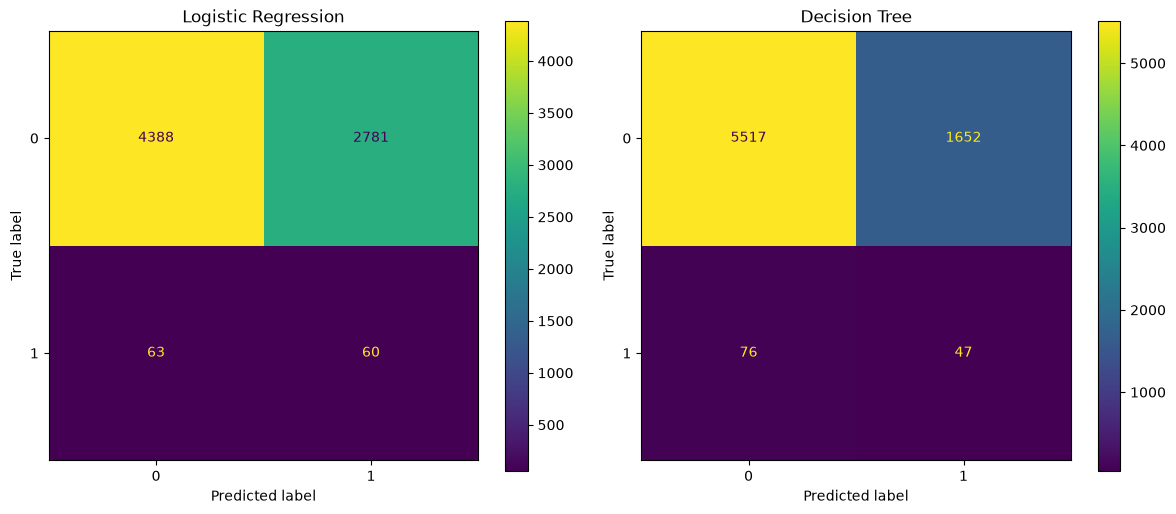

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1])
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

### ROC Curves Compared

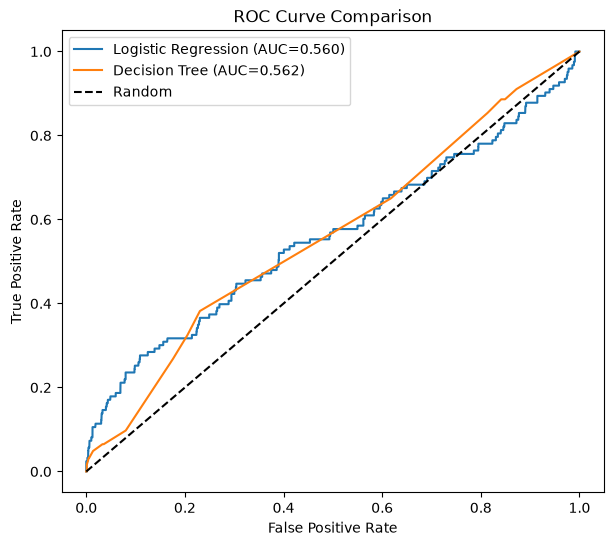

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_score(y_test, y_proba_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [8]:
import json

baseline_results = {
    'logistic_regression': {'roc_auc': float(roc_auc_score(y_test, y_proba_lr))},
    'decision_tree': {'roc_auc': float(roc_auc_score(y_test, y_proba_dt))}
}

with open('../data/processed/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)